<a href="https://colab.research.google.com/github/5star55/EDA-Exercise/blob/main/Cat_%26_Num.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import matplotlib.ticker as mtick
%matplotlib inline

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
telco_base_data=pd.read_csv('/content/drive/MyDrive/Learning-data-analytics/Churn_Modelling.csv')

In [6]:
telco_base_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
telco_base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
telco_base_data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
exited_customers = telco_base_data[telco_base_data['Exited'] == 1].shape[0]
print(f"Number of customers who exited: {exited_customers}")

Number of customers who exited: 2037


In [10]:
new_telco=telco_base_data[['Geography', 'Gender','Exited']]

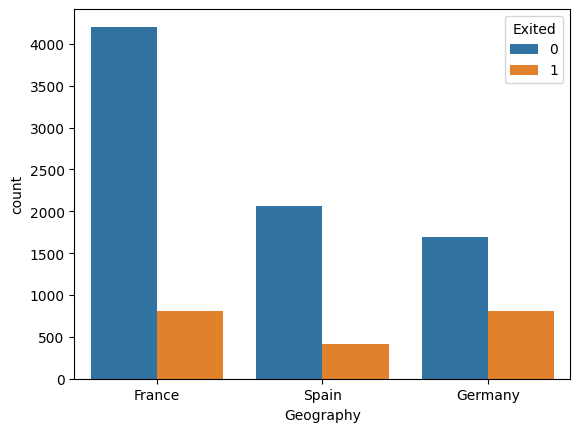

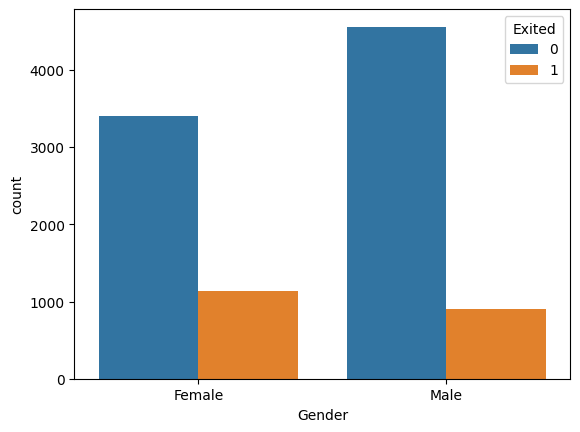

In [11]:
for i, predictor in enumerate(new_telco.drop(columns=['Exited'])):
  plt.figure()
  sns.countplot(data=new_telco, x=predictor, hue='Exited')

-People in Germany are more likely to church


-Females are most likely to churn

<Axes: xlabel='Gender', ylabel='Count'>

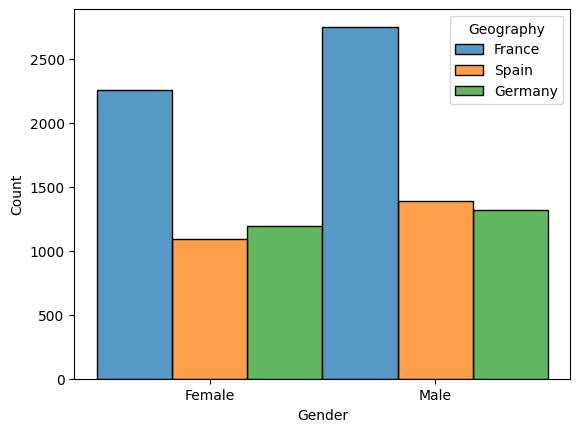

In [12]:
sns.histplot(x='Gender', hue='Geography', multiple='dodge',stat='count', data=new_telco)

In [13]:
telco_churned=telco_base_data[telco_base_data['Exited'] == 1]

In [14]:
telco_churned.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1


<Axes: xlabel='Gender', ylabel='Count'>

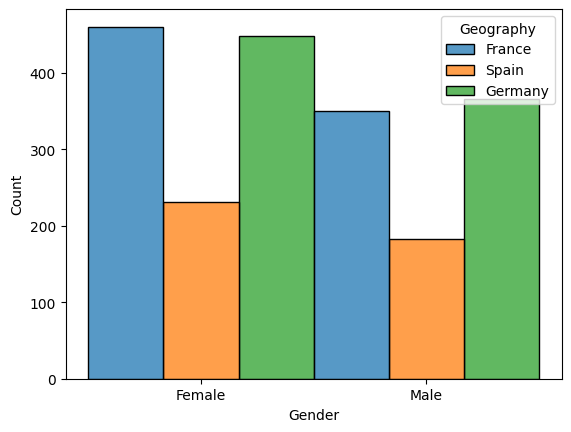

In [15]:
sns.histplot(x='Gender', hue='Geography', multiple='dodge',stat='count', data=telco_churned)

-Females in Germany tend to churn

#Numerical Analysis

Correlation

In [16]:
telco_base_data.select_dtypes(include=np.number).corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


<Axes: >

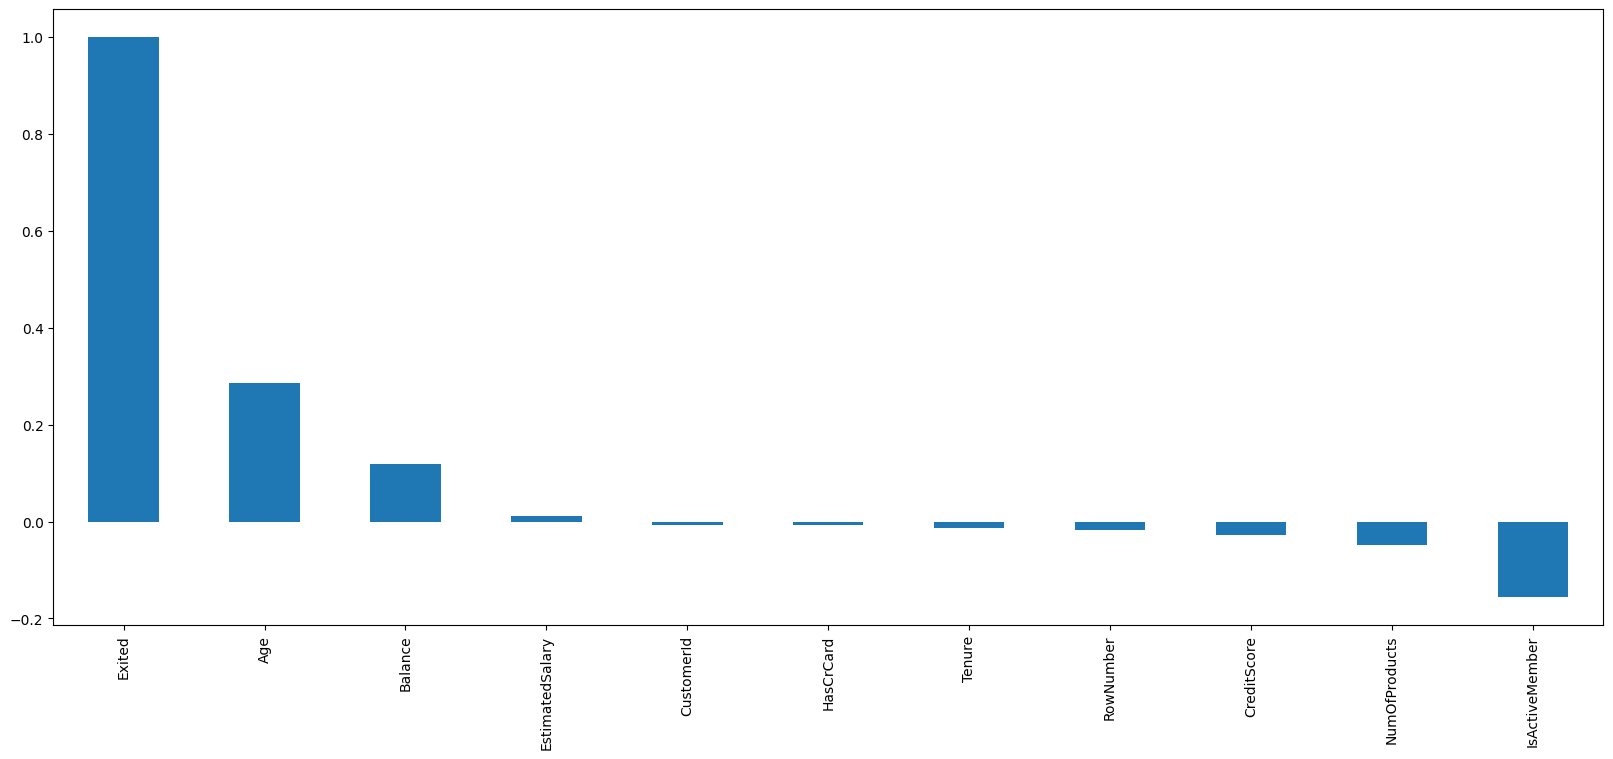

In [17]:
plt.figure(figsize=(20,8))
telco_base_data.select_dtypes(include=np.number).corr()['Exited'].sort_values(ascending=False).plot(kind='bar')

-Older people tend to churn more


-People with higher balance tend to churn

<Axes: >

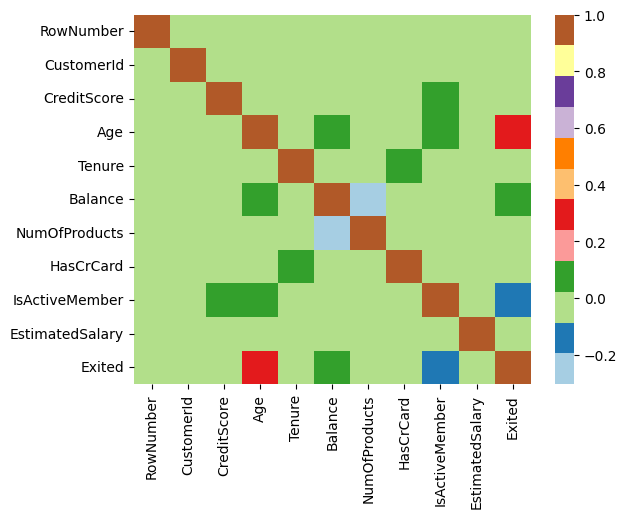

In [18]:
sns.heatmap(telco_base_data.select_dtypes(include=np.number).corr(), cmap='Paired')

#Derived Metrics

<Axes: ylabel='Frequency'>

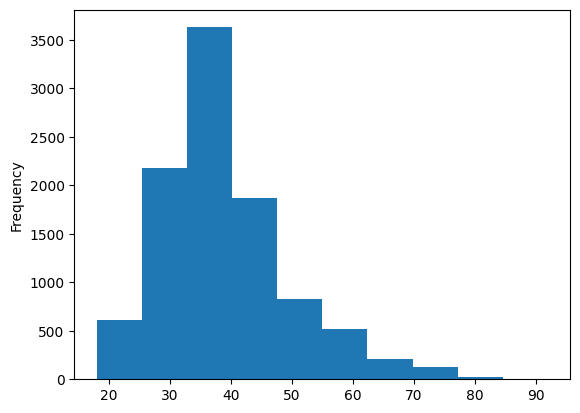

In [19]:
telco_base_data['Age'].plot(kind='hist')

In [20]:
telco_base_data['Age'].value_counts()

,count
Age,
37,478
38,477
35,474
36,456
34,447
...,...
84,2
82,1
88,1


In [21]:
telco_base_data['Age'].value_counts().sort_values()

,count
Age,
85,1
83,1
82,1
88,1
84,2
...,...
34,447
36,456
35,474


<Axes: xlabel='Age'>

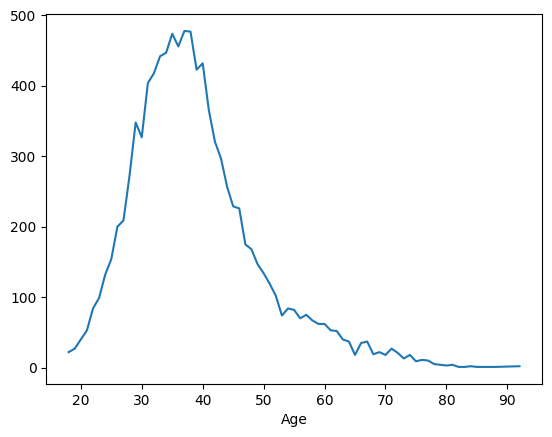

In [22]:
telco_base_data['Age'].value_counts().sort_index().plot(kind='line')

In [23]:
telco_churned['Age'].value_counts()

,count
Age,
46,91
40,89
43,88
45,87
48,80
42,77
47,77
49,75
44,73


<Axes: xlabel='Age'>

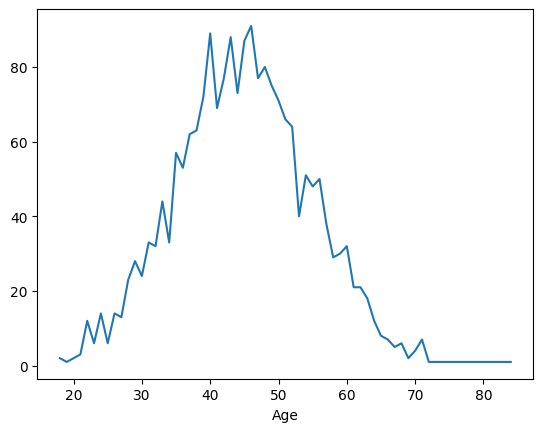

In [24]:
telco_churned['Age'].value_counts().sort_index(ascending=True).plot(kind='line')

-People who are churning are older in age

Text(0.5, 1.0, 'Age Distribution of Exited and Not Exited Customers')

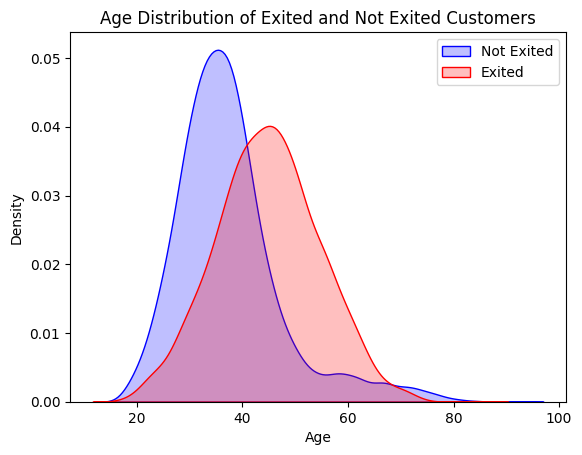

In [43]:
tot=sns.kdeplot(data=telco_base_data[telco_base_data['Exited'] == 0]['Age'], fill=True, color='Blue')
tot=sns.kdeplot(data=telco_churned[telco_churned['Exited']==1]['Age'],fill=True, color='Red')
tot.legend(['Not Exited', 'Exited'],loc='upper right')
tot.set_xlabel('Age')
tot.set_ylabel('Density')
tot.set_title('Age Distribution of Exited and Not Exited Customers')


Text(0, 0.5, 'Density')

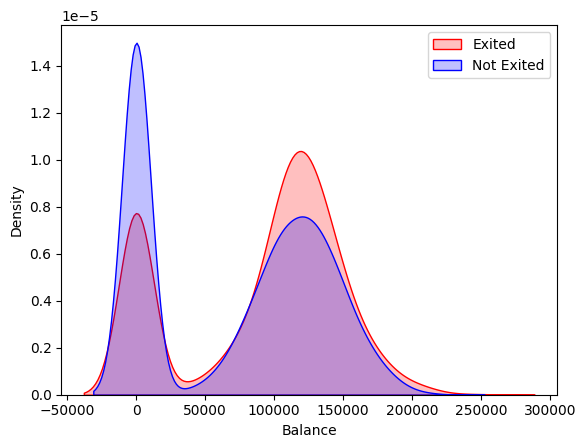

In [47]:
tot=sns.kdeplot(telco_base_data.Balance[telco_base_data['Exited']==1], fill=True, color='Red')
tot=sns.kdeplot(telco_base_data.Balance[telco_base_data['Exited']==0], fill=True, color='Blue')
tot.legend(['Exited','Not Exited'], loc='upper right')
tot.set_xlabel('Balance')
tot.set_ylabel('Density')